In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data import load_banking77, load_clinc_oos_queries

sns.set_theme(style="whitegrid")

train_df, test_df = load_banking77()
oos_df = load_clinc_oos_queries()

print(train_df.shape, test_df.shape, oos_df.shape)
train_df.head()

(10003, 3) (3080, 3) (1000, 1)


,text,intent,label
0,I am still waiting on my card?,card_arrival,12
1,What can I do if my card still hasn't arrived ...,card_arrival,12
2,I have been waiting over a week. Is the card s...,card_arrival,12
3,Can I track my card while it is in the process...,card_arrival,12
4,"How do I know if I will get my card, or if it ...",card_arrival,12


In [2]:
print("--- dtypes ---")
print(train_df.dtypes)

print("\n--- nulls ---")
print(train_df.isna().sum().to_dict(), test_df.isna().sum().to_dict())

print("\n--- empty strings ---")
print((train_df["text"].str.len() == 0).sum(), (test_df["text"].str.len() == 0).sum())

print("\n--- exact duplicate rows within train ---")
print(train_df.duplicated(subset=["text", "label"]).sum())

train_texts = set(train_df["text"].str.lower())
test_texts = set(test_df["text"].str.lower())
overlap = train_texts & test_texts
print("\n--- train/test text overlap ---")
print(f"{len(overlap)} of {len(test_texts)} unique test texts also appear in train")

print("\n--- intents in test missing from train ---")
print(set(test_df["intent"]) - set(train_df["intent"]))

--- dtypes ---
text      object
intent    object
label      int64
dtype: object

--- nulls ---
{'text': 0, 'intent': 0, 'label': 0} {'text': 0, 'intent': 0, 'label': 0}

--- empty strings ---
0 0

--- exact duplicate rows within train ---
4

--- train/test text overlap ---
6 of 3079 unique test texts also appear in train

--- intents in test missing from train ---
set()


In [3]:
counts = train_df["intent"].value_counts()

print(f"n_intents      : {counts.size}")
print(f"min / max      : {counts.min()} / {counts.max()}")
print(f"mean / median  : {counts.mean():.1f} / {counts.median():.1f}")
print(f"imbalance ratio: {counts.max() / counts.min():.2f}")

fig, ax = plt.subplots(figsize=(12, 8))
counts.sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("training examples")
ax.set_ylabel("")
ax.set_title("BANKING77 — training examples per intent")
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()

print("\nsmallest 10:\n", counts.tail(10))

n_intents      : 77
min / max      : 35 / 187
mean / median  : 129.9 / 127.0
imbalance ratio: 5.34


<Figure size 1200x800 with 1 Axes>


smallest 10:
 intent
get_disposable_virtual_card    97
top_up_limits                  97
receiving_money                95
atm_support                    87
compromised_card               86
lost_or_stolen_card            82
card_swallowed                 61
card_acceptance                59
virtual_card_not_working       41
contactless_not_working        35
Name: count, dtype: int64


train  words  mean= 11.9  median= 10.0  p95= 29.0  p99= 43.0  max=79
test   words  mean= 11.0  median=  9.0  p95= 24.0  p99= 38.2  max=69
oos    words  mean=  8.7  median=  8.0  p95= 14.0  p99= 16.0  max=20


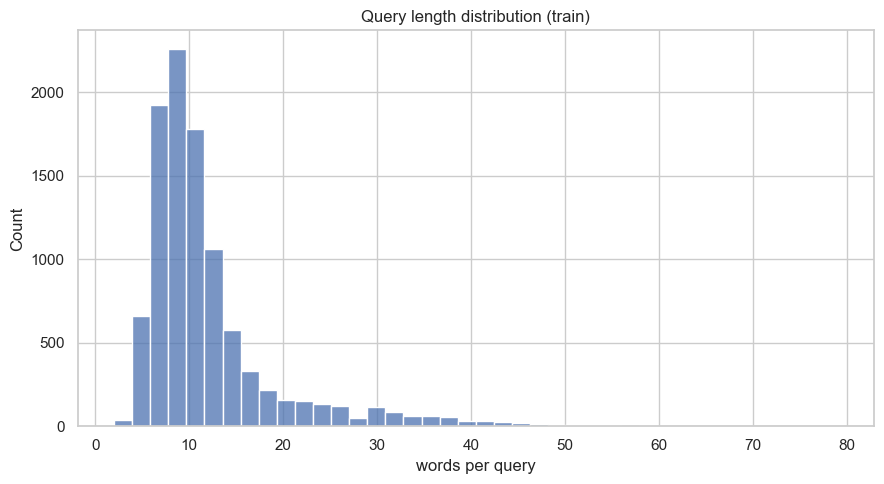

In [4]:
for name, frame in [("train", train_df), ("test", test_df), ("oos", oos_df)]:
    words = frame["text"].str.split().str.len()
    print(f"{name:6s} words  mean={words.mean():5.1f}  median={words.median():5.1f}  "
          f"p95={words.quantile(0.95):5.1f}  p99={words.quantile(0.99):5.1f}  max={words.max()}")

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(train_df["text"].str.split().str.len(), bins=40, ax=ax, color="#4c72b0")
ax.set_xlabel("words per query")
ax.set_title("Query length distribution (train)")
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "length_distribution.png", dpi=150)
plt.show()

In [5]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

lengths = np.array([len(tok.encode(t)) for t in train_df["text"]])

for q in (0.5, 0.9, 0.95, 0.99, 1.0):
    print(f"p{int(q*100):<3d} tokens: {np.quantile(lengths, q):.0f}")

for cap in (32, 48, 64, 128):
    print(f"max_length={cap:3d} → {100 * (lengths <= cap).mean():.2f}% of queries fit uncut")

/Users/manalfatima/projects/banking-intent-router/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

p50  tokens: 13
p90  tokens: 28
p95  tokens: 37
p99  tokens: 53
p100 tokens: 98
max_length= 32 → 92.99% of queries fit uncut
max_length= 48 → 98.53% of queries fit uncut
max_length= 64 → 99.70% of queries fit uncut
max_length=128 → 100.00% of queries fit uncut


In [7]:
import importlib
import src.splits
importlib.reload(src.splits)

splits = src.splits.build_splits()

for name, frame in splits.items():
    n_classes = frame["label"].nunique()
    print(f"{name:12s} rows={len(frame):5d}  distinct_labels={n_classes:3d}")

print("\nlabel range in train:", splits["train"]["label"].min(), "-", splits["train"]["label"].max())
print("val class count min/max:", splits["val"]["label"].value_counts().min(),
      "/", splits["val"]["label"].value_counts().max())
print("\nheld-out test sample:")
print(splits["test_idoos"][["text", "intent"]].head(3).to_string(index=False))

train        rows= 8103  distinct_labels= 70
val          rows= 1430  distinct_labels= 70
test_in      rows= 2800  distinct_labels= 70
test_idoos   rows=  280  distinct_labels=  1
test_oodoos  rows= 1000  distinct_labels=  1

label range in train: 0 - 69
val class count min/max: 13 / 28

held-out test sample:
                                                                                                                                                          text              intent
My entire gym bag, including my wallet, was stolen out of my locker today. Everything in my wallet is gone - how do I block the card to make it can't be used? lost_or_stolen_card
                                                                                                       I can't find my card and think it may have been stolen. lost_or_stolen_card
                                           Someone stole my card. I need to report it stolen. I made a police report already, but how do I report it wit